In [1]:
from datetime import datetime
from datetime import datetime
from pathlib import Path
import json
import json

import optuna
import polars as pl
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt


DATA_DIR = Path("..") / "data" / "scaled"
X_TRAIN_FILE = DATA_DIR / "X_train.parquet"
Y_TRAIN_FILE = DATA_DIR / "y_train.parquet"
X_TEST_FILE = DATA_DIR / "X_test.parquet"
Y_TEST_FILE = DATA_DIR / "y_test.parquet"
MODEL_DIR = Path("..") / "model"
RESULTS_DIR = MODEL_DIR / "results"
TARGET_COLUMN = "label"
RANDOM_SEED = 42
MODEL_NAME = "xgboost"

In [2]:
for required_file in [X_TRAIN_FILE, Y_TRAIN_FILE, X_TEST_FILE, Y_TEST_FILE]:
    if not required_file.exists():
        raise FileNotFoundError(f"Required parquet file not found: {required_file}")

X_train = pl.read_parquet(X_TRAIN_FILE)
y_train_df = pl.read_parquet(Y_TRAIN_FILE)
X_test = pl.read_parquet(X_TEST_FILE)
y_test_df = pl.read_parquet(Y_TEST_FILE)

print(f"loaded X_train: {X_train.shape}")
print(f"loaded y_train: {y_train_df.shape}")
print(f"loaded X_test: {X_test.shape}")
print(f"loaded y_test: {y_test_df.shape}")

loaded X_train: (71236, 305)
loaded y_train: (71236, 1)
loaded X_test: (30530, 305)
loaded y_test: (30530, 1)


In [3]:
y_train = y_train_df.get_column(TARGET_COLUMN).cast(pl.Int32)
y_test = y_test_df.get_column(TARGET_COLUMN).cast(pl.Int32)

print(f"feature columns: {len(X_train.columns)}")
print(f"target column: {TARGET_COLUMN}")

feature columns: 305
target column: label


In [4]:
# Calculate the positive weight
positive_weight = y_train_df.to_pandas().value_counts().iloc[0] / y_train_df.to_pandas().value_counts().iloc[1]
print(f"The balanced weight for the loss function is {positive_weight:.3f}")

#Define the classifier.
XGB_Placement = XGBClassifier(max_depth=3,                 # Depth of each tree
                            learning_rate=0.1,            # How much to shrink error in each subsequent training. Trade-off with no. estimators.
                            n_estimators=100,             # How many trees to use, the more the better, but decrease learning rate if many used.
                            verbosity=1,                  # If to show more errors or not.
                            objective='binary:logistic',     # Type of target variable.
                            booster='gbtree',             # What to boost. Trees in this case.
                            n_jobs=-1,                     # Parallel jobs to run. Set your processor number.
                            gamma=0.001,                  # Minimum loss reduction required to make a further partition on a leaf node of the tree. (Controls growth!)
                            subsample=0.632,              # Subsample ratio. Can set lower
                            colsample_bytree=1,           # Subsample ratio of columns when constructing each tree.
                            colsample_bylevel=1,          # Subsample ratio of columns when constructing each level. 0.33 is similar to random forest.
                            colsample_bynode=1,           # Subsample ratio of columns when constructing each split.
                            base_score=0.5,               # Global bias. Set to average of the target rate.
                            random_state=20201107        # Seed
                            )

The balanced weight for the loss function is 7.961


In [5]:
# Define the parameters. Play with this grid!
param_grid = dict({'n_estimators': [100, 150, 200],
                   'max_depth': [2, 3],
                 'learning_rate' : [0.05, 0.1, 0.15, 0.2]
                  })
param_grid

{'n_estimators': [100, 150, 200],
 'max_depth': [2, 3],
 'learning_rate': [0.05, 0.1, 0.15, 0.2]}

In [6]:
# If the dataset is too big, you can always create a validation set over which to do the parameter search.
val_sample = X_train.with_columns(
    pl.Series("label", y_train.to_numpy().ravel())
).sample(fraction=0.6)

val_sample.describe()

statistic,num__age,num__time_in_hospital,num__num_lab_procedures,num__num_procedures,num__num_medications,num__number_outpatient,num__number_emergency,num__number_inpatient,num__number_diagnoses,ord__max_glu_serum,ord__A1Cresult,cat__race_AfricanAmerican,cat__race_Asian,cat__race_Caucasian,cat__race_Hispanic,cat__race_Other,cat__gender_Female,cat__gender_Male,cat__gender_Unknown/Invalid,cat__payer_code_Other,cat__payer_code_Private,cat__payer_code_Public,cat__payer_code_Uninsured,cat__medical_specialty_?,cat__medical_specialty_AllergyandImmunology,cat__medical_specialty_Anesthesiology,cat__medical_specialty_Anesthesiology-Pediatric,cat__medical_specialty_Cardiology,cat__medical_specialty_Cardiology-Pediatric,cat__medical_specialty_DCPTEAM,cat__medical_specialty_Dentistry,cat__medical_specialty_Emergency/Trauma,cat__medical_specialty_Endocrinology,cat__medical_specialty_Endocrinology-Metabolism,cat__medical_specialty_Family/GeneralPractice,cat__medical_specialty_Gastroenterology,…,cat__admission_source_Normal Delivery,cat__admission_source_Not Available,cat__admission_source_Not Mapped,cat__admission_source_Physician Referral,cat__admission_source_Transfer from Ambulatory Surgery Center,cat__admission_source_Transfer from a Skilled Nursing Facility (SNF),cat__admission_source_Transfer from a hospital,cat__admission_source_Transfer from another health care facility,cat__admission_source_Transfer from critial access hospital,cat__admission_source_Transfer from hospital inpt/same fac reslt in a sep claim,cat__discharge_disposition_Admitted as an inpatient to this hospital,cat__discharge_disposition_Discharged to home,cat__discharge_disposition_Discharged/transferred to ICF,cat__discharge_disposition_Discharged/transferred to SNF,cat__discharge_disposition_Discharged/transferred to a federal health care facility.,cat__discharge_disposition_Discharged/transferred to a long term care hospital.,cat__discharge_disposition_Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.,cat__discharge_disposition_Discharged/transferred to another rehab fac including rehab units of a hospital .,cat__discharge_disposition_Discharged/transferred to another short term hospital,cat__discharge_disposition_Discharged/transferred to another type of inpatient care institution,cat__discharge_disposition_Discharged/transferred to home under care of Home IV provider,cat__discharge_disposition_Discharged/transferred to home with home health service,cat__discharge_disposition_Discharged/transferred within this institution to Medicare approved swing bed,cat__discharge_disposition_Discharged/transferred/referred another institution for outpatient services,cat__discharge_disposition_Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital,cat__discharge_disposition_Discharged/transferred/referred to this institution for outpatient services,cat__discharge_disposition_Expired,cat__discharge_disposition_Expired at home. Medicaid only; hospice.,cat__discharge_disposition_Expired in a medical facility. Medicaid only; hospice.,cat__discharge_disposition_Hospice / home,cat__discharge_disposition_Hospice / medical facility,cat__discharge_disposition_Left AMA,cat__discharge_disposition_NULL,cat__discharge_disposition_Neonate discharged to another hospital for neonatal aftercare,cat__discharge_disposition_Not Mapped,cat__discharge_disposition_Still patient or expected to return for outpatient services,label
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,42741.0,

In [7]:
# Define the cross-validation object. We'll use 3-fold cross-validation.
cv_object = StratifiedKFold(n_splits = 3,
                            shuffle = True,
                            random_state = 20250304)



# Define grid search object.
GridXGB = GridSearchCV(XGB_Placement,        # Original XGB.
                       param_grid,          # Parameter grid
                       cv = cv_object,      # Cross-validation object.
                       scoring = 'roc_auc', # How to rank outputs.
                       n_jobs = -1,          # Parallel jobs. -1 is "all you have"
                       refit = False,       # If refit at the end with the best. We'll do it manually.
                       verbose = 1          # If to show what it is doing.
                      )

# Define a pipeline with the preprocessor and the classifier
XGB_pipe = Pipeline(
    steps=[
         ("classifier", GridXGB)]
)

In [8]:
# Train grid search.
XGB_pipe.fit(val_sample.drop("label").to_pandas(),
             val_sample.select("label").to_numpy().ravel())

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [2, 3], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to 

In [9]:
XGB_pipe.named_steps["classifier"].best_params_

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

In [10]:
XGB_pipe.named_steps["classifier"].cv_results_

{'mean_fit_time': array([2.0749321 , 2.31388497, 2.55458188, 1.58861995, 1.96456814,
        2.45286409, 1.36662324, 1.85864774, 2.26606933, 1.46461964,
        1.95897253, 2.4670856 , 1.3940928 , 1.79127471, 2.22259998,
        1.49536538, 1.94827859, 2.45542105, 1.3435545 , 1.78735129,
        2.2812957 , 1.49650407, 1.86187967, 1.92511582]),
 'std_fit_time': array([0.03367365, 0.17740055, 0.3156651 , 0.02372788, 0.07721702,
        0.09253467, 0.01426387, 0.03947413, 0.10426524, 0.02618664,
        0.07539964, 0.02430292, 0.03292162, 0.06612765, 0.05286656,
        0.08314385, 0.04692701, 0.00349977, 0.02090307, 0.08588599,
        0.09727168, 0.09936283, 0.03142681, 0.12120287]),
 'mean_score_time': array([0.05334314, 0.10852369, 0.07188106, 0.06009277, 0.06686823,
        0.07039825, 0.07226292, 0.08502165, 0.07628544, 0.06044555,
        0.08662732, 0.06029105, 0.03951891, 0.05332669, 0.07632192,
        0.07351661, 0.08222485, 0.05624302, 0.04770311, 0.06717078,
        0.054257

In [11]:
# Create XGB with best parameters.
XGB_Placement = XGBClassifier(max_depth=XGB_pipe.named_steps["classifier"].best_params_.get('max_depth'), # Depth of each tree
                            learning_rate=XGB_pipe.named_steps["classifier"].best_params_.get('learning_rate'), # How much to shrink error in each subsequent training. Trade-off with no. estimators.
                            n_estimators=XGB_pipe.named_steps["classifier"].best_params_.get('n_estimators'), # How many trees to use, the more the better, but decrease learning rate if many used.
                            verbosity=1,                  # If to show more errors or not.
                            objective='binary:logistic',  # Type of target variable.
                            booster='gbtree',             # What to boost. Trees in this case.
                            n_jobs=-1,                     # Parallel jobs to run. Set your processor number.
                            gamma=0.001,                  # Minimum loss reduction required to make a further partition on a leaf node of the tree. (Controls growth!)
                            subsample=0.632,                  # Subsample ratio. Can set lower
                            colsample_bytree=1,           # Subsample ratio of columns when constructing each tree.
                            colsample_bylevel=1,          # Subsample ratio of columns when constructing each level. 0.33 is similar to random forest.
                            colsample_bynode=1,           # Subsample ratio of columns when constructing each split.
                            reg_alpha=1,                  # Regularizer for first fit. alpha = 1, lambda = 0 is LASSO.
                            reg_lambda=0,                 # Regularizer for first fit.
                            scale_pos_weight=1,           # Balancing of positive and negative weights.
                            base_score=0.5,               # Global bias. Set to average of the target rate.
                            random_state=20201107,        # Seed
                            )

# Define a pipeline with the preprocessor and the classifier
XGB_pipe = Pipeline(
    steps=[
         ("classifier", XGB_Placement)]
)

In [12]:
# Train the pipeline
XGB_pipe.fit(X_train.to_pandas(), y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,1
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,1
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1


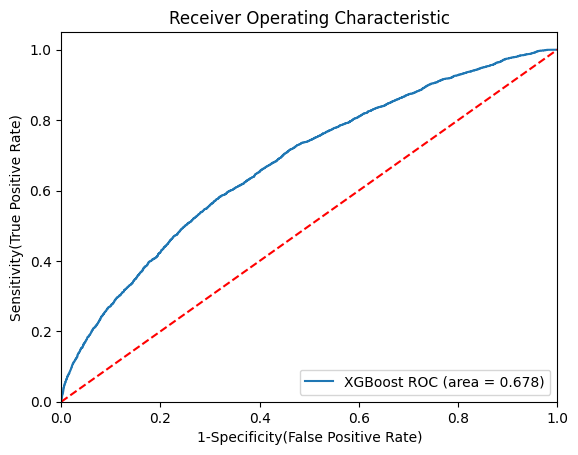

In [13]:
# Calculate probability
xgb_prob_test = XGB_pipe.predict_proba(X_test.to_pandas())
xgb_prob_test = xgb_prob_test[:, 1]

# Set models and probabilities. This structure is called a dictionary.
models = [
{
    'label': 'XGBoost',
    'probs': xgb_prob_test
},
]

# Loop that creates the plot. I will pass each ROC curve one by one.
for m in models:
  auc = roc_auc_score(y_true = y_test,
                             y_score = m['probs'])
  fpr, tpr, thresholds = roc_curve(y_test,
                                           m['probs'])
  plt.plot(fpr, tpr, label=f'{m["label"]} ROC (area = {auc:.3f})')



# Settings
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")

# Plot!
plt.show()